<a href="https://colab.research.google.com/github/vruddhis/semanticshift/blob/main/notebooks/new_metric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cosine
from itertools import combinations
from scipy.stats import entropy
import ast
import matplotlib.pyplot as plt
import seaborn as sns


In [43]:
formal_df = pd.read_csv(
    "all formal words with embeddings.csv",
    engine="python",
    on_bad_lines="skip"
)

informal_df = pd.read_csv(
    "all informal words with embeddings.csv",
    engine="python",
    on_bad_lines="skip"
)


df = pd.concat([formal_df, informal_df], ignore_index=True)


In [55]:
def group_embeddings(df):
    grouped = {}
    for (word, event, period), g in df.groupby(["word", "event", "period"]):
        grouped.setdefault((word, event), {})[period] = np.vstack(g["embedding"].values)
    return grouped

grouped = group_embeddings(df)


In [44]:
def register_shift(word, event, metric):
    Ei_formal = event_impact(word, event, "formal", metric)
    Ei_informal = event_impact(word, event, "informal", metric)

    if np.isnan(Ei_formal) or np.isnan(Ei_informal):
        return np.nan

    return abs(Ei_formal - Ei_informal)


In [45]:
df["embedding"] = df["embedding"].apply(ast.literal_eval)
df["embedding"] = df["embedding"].apply(np.array)


In [46]:
def prototype(embeddings):
    return np.mean(embeddings, axis=0)


In [47]:
def cosine_shift(embs_a, embs_b):
    return cosine(prototype(embs_a), prototype(embs_b))


In [48]:
def apd(embs_a, embs_b):
    dists = [
        cosine(x, y)
        for x in embs_a
        for y in embs_b
    ]
    return np.mean(dists)


In [49]:
def context_entropy(embeddings, bins=20):
    norms = np.linalg.norm(embeddings, axis=1)
    hist, _ = np.histogram(norms, bins=bins, density=True)
    hist = hist + 1e-9  # smoothing
    return entropy(hist)


In [50]:
def entropy_shift(embs_a, embs_b):
    return context_entropy(embs_b) - context_entropy(embs_a)


In [51]:
def semantic_divergence(periods):
    if "before" in periods and "after" in periods:
        return cosine_shift(periods["before"], periods["after"])
    return np.nan


In [52]:
def event_impact(periods):
    if "before" in periods and "during" in periods:
        return cosine_shift(periods["before"], periods["during"])
    return np.nan


In [53]:
def shift_variants(sd, ei):
    return {
        "shift_long": sd,                      # Variant A
        "shift_event": ei,                     # Variant B
        "shift_balanced": 0.5*sd + 0.5*ei,     # Variant C
        "shift_event_heavy": 0.3*sd + 0.7*ei   # Variant D
    }


In [56]:
rows = []

for (word, event), periods in grouped.items():
    sd = semantic_divergence(periods)
    ei = event_impact(periods)

    if np.isnan(sd) or np.isnan(ei):
        continue

    shifts = shift_variants(sd, ei)

    rows.append({
        "word": word,
        "event": event,
        "semantic_divergence": sd,
        "event_impact": ei,
        **shifts
    })

results_df = pd.DataFrame(rows)
results_df


,word,event,semantic_divergence,event_impact,shift_long,shift_event,shift_balanced,shift_event_heavy
0,algorithm,ai-automation,0.001989,0.004441,0.001989,0.004441,0.003215,0.003705
1,binge,streaming,0.046221,0.021412,0.046221,0.021412,0.033817,0.028855
2,bubble,covid-19,0.003061,0.004421,0.003061,0.004421,0.003741,0.004013
3,drop,nft,0.008675,0.002714,0.008675,0.002714,0.005695,0.004502
4,prompt,chatgpt-launch,0.004121,0.177345,0.004121,0.177345,0.090733,0.125378
5,remote,covid-19,0.012885,0.006730,0.012885,0.006730,0.009807,0.008576
6,spoiler,streaming,0.006758,0.003216,0.006758,0.003216,0.004987,0.004278
7,stream,streaming,0.005047,0.001815,0.005047,0.001815,0.003431,0.002784
8,tag,social-media,0.002607,0.001276,0.002607,0.001276,0.001941,0.001675
9,token,nft,0.007794,0.002200,0.007794,0.002200,0.004997,0.003878


In [57]:
print(results_df.shape)
results_df.head()


(12, 8)


,word,event,semantic_divergence,event_impact,shift_long,shift_event,shift_balanced,shift_event_heavy
0,algorithm,ai-automation,0.001989,0.004441,0.001989,0.004441,0.003215,0.003705
1,binge,streaming,0.046221,0.021412,0.046221,0.021412,0.033817,0.028855
2,bubble,covid-19,0.003061,0.004421,0.003061,0.004421,0.003741,0.004013
3,drop,nft,0.008675,0.002714,0.008675,0.002714,0.005695,0.004502
4,prompt,chatgpt-launch,0.004121,0.177345,0.004121,0.177345,0.090733,0.125378


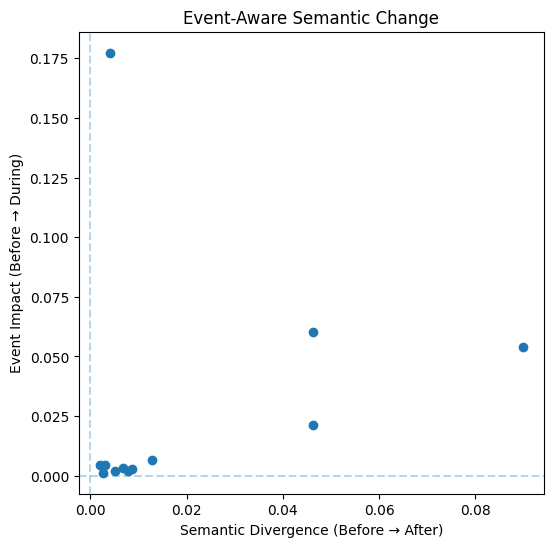

In [59]:
plt.figure(figsize=(6,6))
plt.scatter(results_df["semantic_divergence"],
            results_df["event_impact"])

plt.xlabel("Semantic Divergence (Before → After)")
plt.ylabel("Event Impact (Before → During)")
plt.title("Event-Aware Semantic Change")

plt.axhline(0, linestyle="--", alpha=0.3)
plt.axvline(0, linestyle="--", alpha=0.3)
plt.show()


In [60]:
def interpret(row):
    if row.event_impact > row.semantic_divergence:
        return "Event-driven spike"
    elif row.semantic_divergence > row.event_impact:
        return "Gradual semantic drift"
    else:
        return "Mixed change"

results_df["interpretation"] = results_df.apply(interpret, axis=1)


In [61]:
results_df.to_csv('results.csv')

In [62]:
results_df[
    ["semantic_divergence", "event_impact",
     "shift_balanced", "shift_event_heavy"]
].corr()


,semantic_divergence,event_impact,shift_balanced,shift_event_heavy
semantic_divergence,1.000000,0.188260,0.590504,0.389673
event_impact,0.188260,1.000000,0.903773,0.977846
shift_balanced,0.590504,0.903773,1.000000,0.973345
shift_event_heavy,0.389673,0.977846,0.973345,1.000000


In [63]:
results_df["rank_event"] = results_df["event_impact"].rank(ascending=False)
results_df["rank_long"] = results_df["semantic_divergence"].rank(ascending=False)

results_df.sort_values("rank_event").head()


,word,event,semantic_divergence,event_impact,shift_long,shift_event,shift_balanced,shift_event_heavy,interpretation,rank_event,rank_long
4,prompt,chatgpt-launch,0.004121,0.177345,0.004121,0.177345,0.090733,0.125378,Event-driven spike,1.0,9.0
11,variant,covid-19,0.046281,0.060101,0.046281,0.060101,0.053191,0.055955,Event-driven spike,2.0,2.0
10,tweet,social-media,0.089802,0.054189,0.089802,0.054189,0.071996,0.064873,Gradual semantic drift,3.0,1.0
1,binge,streaming,0.046221,0.021412,0.046221,0.021412,0.033817,0.028855,Gradual semantic drift,4.0,3.0
5,remote,covid-19,0.012885,0.006730,0.012885,0.006730,0.009807,0.008576,Gradual semantic drift,5.0,4.0
